In [ ]:
import time
import pandas as pd
from nba_api.stats.endpoints import synergyplaytypes

PROJECT_DIR = "/Users/mikey/Downloads/Eclipse_SP26_Project"

seasons = ["2022-23", "2023-24", "2024-25", "2025-26"]
play_types = {
    "PRBallHandler": "Ball Handler",
    "PRRollMan": "Roll Man",
}
all_data = []

for season in seasons:
    for play_type, label in play_types.items():
        print(f"Fetching data for {season} - {label}...")
        try:
            pr = synergyplaytypes.SynergyPlayTypes(
                play_type_nullable=play_type,
                per_mode_simple="Totals",
                player_or_team_abbreviation="P",
                season=season,
                season_type_all_star="Regular Season",
                type_grouping_nullable="offensive",
            )
            p&r_data = pr.get_data_frames()[0]
            p&r_data["Season"] = season
            p&r_data["PlayType"] = label
            all_data.append(p&r_data)
        except Exception as e:
            print(f"Failed for {season} {label}: {e}")
        time.sleep(2)

combined = pd.concat(all_data, ignore_index=True)

numeric_cols = ["POSS", "PPP", "FG_PCT", "EFG_PCT"]
combined[numeric_cols] = combined[numeric_cols].apply(pd.to_numeric, errors="coerce")
combined = combined[combined["POSS"] >= 100].copy()

combined.to_csv(f"{PROJECT_DIR}/p&r_data.csv", index=False)
print(f"Done. {len(combined)} player-seasons saved.")
print(combined.shape)
print(combined.isnull().sum())

SyntaxError: cannot assign to expression here. Maybe you meant '==' instead of '='? (2570532469.py, line 26)

In [ ]:
import pandas as pd

PROJECT_DIR = "/Users/mikey/Downloads/Eclipse_SP26_Project"
p&r_data = pd.read_csv(f"{PROJECT_DIR}/p&r_data.csv")

# --- Aggregate mid-season trade players ---
count_cols = ["POSS", "PTS", "FGM", "FGA", "GP"]
rate_cols  = ["EFG_PCT", "FT_POSS_PCT", "TOV_POSS_PCT",
              "SF_POSS_PCT", "PLUSONE_POSS_PCT", "SCORE_POSS_PCT", "POSS_PCT"]

key = ["PLAYER_ID", "PLAYER_NAME", "Season", "PlayType"]

def aggregate_group(g):
    row = g.iloc[0].copy()
    for col in count_cols:
        row[col] = g[col].sum()
    for col in rate_cols:
        row[col] = (g[col] * g["POSS"]).sum() / g["POSS"].sum()
    row["PPP"] = row["PTS"] / row["POSS"]
    row["FG_PCT"] = row["FGM"] / row["FGA"]
    row["TEAM_ABBREVIATION"] = "TOT" if len(g) > 1 else g["TEAM_ABBREVIATION"].iloc[0]
    return row

cleaned = (
    p&r_data.groupby(key, sort=False)
      .apply(aggregate_group, include_groups=False)
      .reset_index(level=key)
      .reset_index(drop=True)
)

# --- Drop redundant columns ---
drop_cols = ["SEASON_ID", "TEAM_ID", "TEAM_NAME", "TYPE_GROUPING", "PLAY_TYPE",
             "PERCENTILE", "FGMX"]
cleaned = cleaned.drop(columns=drop_cols)

# --- Reorder columns ---
ordered = [
    "PLAYER_ID", "PLAYER_NAME", "TEAM_ABBREVIATION", "Season", "PlayType",
    "GP", "POSS", "POSS_PCT",
    "PPP", "FG_PCT", "EFG_PCT",
    "SCORE_POSS_PCT", "TOV_POSS_PCT", "FT_POSS_PCT", "SF_POSS_PCT", "PLUSONE_POSS_PCT",
    "PTS", "FGM", "FGA",
]
cleaned = cleaned[ordered]

# --- Verify ---
print("Shape:", cleaned.shape)
print("Duplicates:", cleaned.duplicated(["PLAYER_ID", "Season", "PlayType"]).sum())
print("\nSeason/PlayType counts:")
print(cleaned.groupby(["Season", "PlayType"]).size().to_string())

cleaned.to_csv(f"{PROJECT_DIR}/p&r_clean.csv", index=False)
print("\nSaved to p&r_clean.csv")
cleaned.head(3)

Shape: (522, 19)
Duplicates: 0

Season/PlayType counts:
Season   PlayType    
2022-23  Roll Man         40
2023-24  Ball Handler    120
         Roll Man         41
2024-25  Ball Handler    125
         Roll Man         38
2025-26  Ball Handler    125
         Roll Man         33

Saved to p&r_clean.csv


,PLAYER_ID,PLAYER_NAME,TEAM_ABBREVIATION,Season,PlayType,GP,POSS,POSS_PCT,PPP,FG_PCT,EFG_PCT,SCORE_POSS_PCT,TOV_POSS_PCT,FT_POSS_PCT,SF_POSS_PCT,PLUSONE_POSS_PCT,PTS,FGM,FGA
0,203954,Joel Embiid,PHI,2022-23,Roll Man,66,440,0.233,1.229545,0.579755,0.610,0.591,0.095,0.214,0.209,0.05,541,189,326
1,202696,Nikola Vučević,CHI,2022-23,Roll Man,82,386,0.285,1.090674,0.522989,0.565,0.503,0.067,0.049,0.049,0.02,421,182,348
2,1629028,Deandre Ayton,PHX,2022-23,Roll Man,67,321,0.293,1.202492,0.617021,0.619,0.601,0.053,0.097,0.100,0.03,386,174,282


## EDA



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from adjustText import adjust_text

%matplotlib inline

PROJECT_DIR = "/Users/mikey/Downloads/Eclipse_SP26_Project"

# Load & filter to most recent 3 seasons
p&r_data = pd.read_csv(f"{PROJECT_DIR}/p&r_clean.csv")
recent_seasons = sorted(p&r_data["Season"].unique())[-3:]
p&r_data = p&r_data[p&r_data["Season"].isin(recent_seasons)].copy()
print(f"Seasons: {recent_seasons}  |  Rows: {len(p&r_data)}")

palette = {"Ball Handler": "#1f77b4", "Roll Man": "#ff7f0e"}

# How many notable outliers to label per panel (split between over/under-performers)
N_OUTLIERS = 8

def short(name):
    parts = name.split()
    return f"{parts[0][0]}. {parts[-1]}" if len(parts) >= 2 else name

def add_regression(ax, x, y, color="black"):
    """Fit OLS, draw dashed line, return (slope, intercept, r)."""
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    slope, intercept, r, _, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 300)
    ax.plot(x_line, slope * x_line + intercept, "--", color=color,
            linewidth=1.8, label=f"Regression  (r = {r:.2f})", zorder=3)
    return slope, intercept, r

def label_outliers(ax, group, x_col, y_col, slope, intercept, dot_color,
                   n=N_OUTLIERS):
    """Label points deviating most from the regression line (largest residuals).

    One label per player (their most extreme season); split between top
    over-performers (above line) and under-performers (below line).
    """
    g = group.dropna(subset=[x_col, y_col]).copy()
    g["resid"] = g[y_col] - (slope * g[x_col] + intercept)
    g = g.loc[g.groupby("PLAYER_NAME")["resid"].apply(lambda s: s.abs().idxmax())]
    n_over = n // 2
    out = pd.concat([g.nlargest(n_over, "resid"), g.nsmallest(n - n_over, "resid")])

    ax.scatter(out[x_col], out[y_col], s=75, zorder=6,
               color=dot_color, edgecolors="black", linewidth=0.9)
    texts = [
        ax.text(row[x_col], row[y_col], short(row["PLAYER_NAME"]),
                fontsize=7.5, fontweight="bold", color="#111111", zorder=7,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))
        for _, row in out.iterrows()
    ]
    adjust_text(
        texts, ax=ax,
        x=out[x_col].values, y=out[y_col].values,
        expand=(1.6, 1.8), force_text=(0.5, 0.7),
        arrowprops=dict(arrowstyle="-", color="#555555", lw=0.6),
    )

Seasons: ['2023-24', '2024-25', '2025-26']  |  Rows: 482


### Plot 1 — PPP Distribution by Play Type

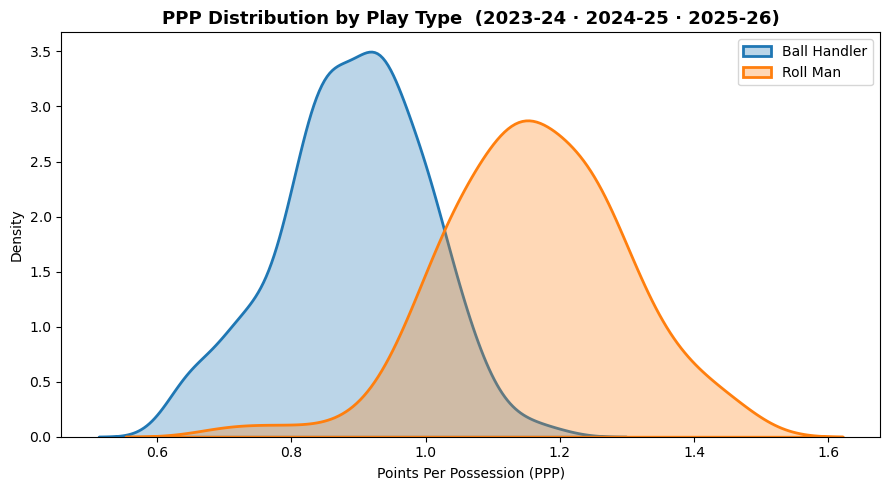

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
for play_type, group in p&r_data.groupby("PlayType"):
    sns.kdeplot(group["PPP"], ax=ax, label=play_type,
                color=palette[play_type], fill=True, alpha=0.3, linewidth=2)
ax.set_title(f"PPP Distribution by Play Type  ({' · '.join(recent_seasons)})",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Points Per Possession (PPP)")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/plot1_ppp_distribution.png", dpi=150)
plt.show()

### Plot 2 — Efficiency vs Volume (PPP vs Possessions)

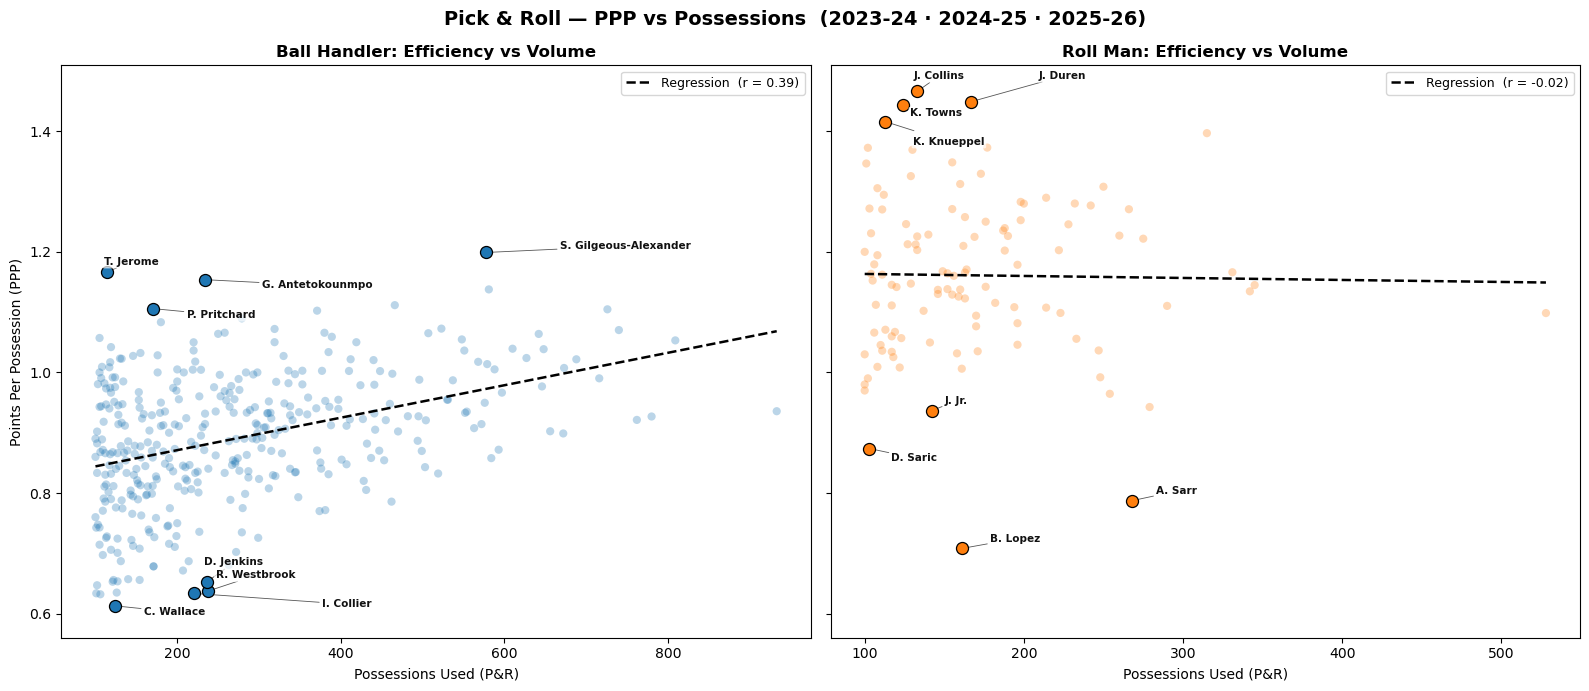

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, (play_type, group) in zip(axes, p&r_data.groupby("PlayType")):
    color = palette[play_type]
    ax.scatter(group["POSS"], group["PPP"], color=color, alpha=0.3, edgecolors="none", s=35)
    slope, intercept, _ = add_regression(ax, group["POSS"].values, group["PPP"].values)
    label_outliers(ax, group, "POSS", "PPP", slope, intercept, color)
    ax.set_title(f"{play_type}: Efficiency vs Volume", fontsize=12, fontweight="bold")
    ax.set_xlabel("Possessions Used (P&R)")
    if ax is axes[0]:
        ax.set_ylabel("Points Per Possession (PPP)")
    ax.legend(fontsize=9)
fig.suptitle(f"Pick & Roll — PPP vs Possessions  ({' · '.join(recent_seasons)})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/plot2_efficiency_volume.png", dpi=150)
plt.show()

### Plot 3 — Average PPP per Season (Trend)

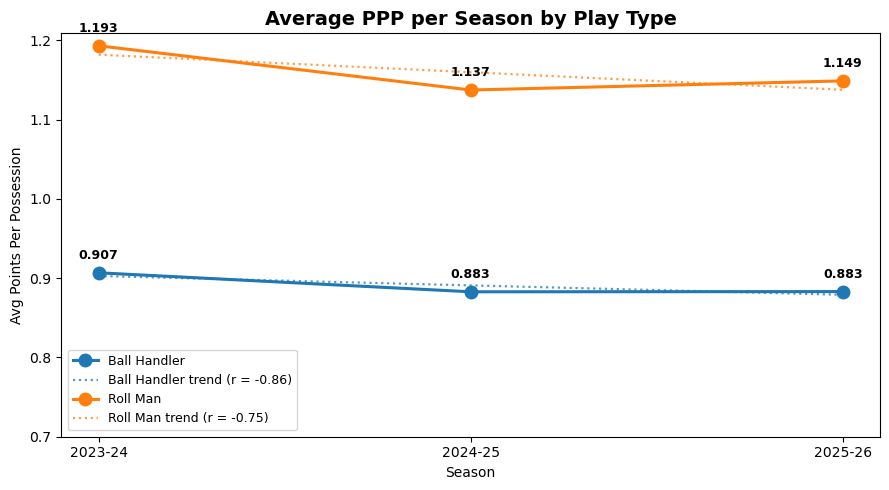

In [ ]:
season_avg = p&r_data.groupby(["Season", "PlayType"])["PPP"].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
for play_type, group in season_avg.groupby("PlayType"):
    group = group.sort_values("Season").reset_index(drop=True)
    color = palette[play_type]
    x_num = np.arange(len(group), dtype=float)
    ax.plot(group["Season"], group["PPP"], marker="o", label=play_type,
            color=color, linewidth=2.2, markersize=9, zorder=4)
    for _, row in group.iterrows():
        ax.annotate(f"{row['PPP']:.3f}", (row["Season"], row["PPP"]),
                    textcoords="offset points", xytext=(0, 10), ha="center",
                    fontsize=9, fontweight="bold")
    slope, intercept, r, _, _ = stats.linregress(x_num, group["PPP"].values)
    ax.plot(group["Season"], intercept + slope * x_num, ":", color=color,
            linewidth=1.6, alpha=0.75, label=f"{play_type} trend (r = {r:.2f})")
ax.set_title("Average PPP per Season by Play Type", fontsize=14, fontweight="bold")
ax.set_xlabel("Season")
ax.set_ylabel("Avg Points Per Possession")
ax.legend(fontsize=9)
ax.set_ylim(bottom=0.7)
plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/plot3_season_trend.png", dpi=150)
plt.show()

### Plot 4 — PPP vs Effective FG%

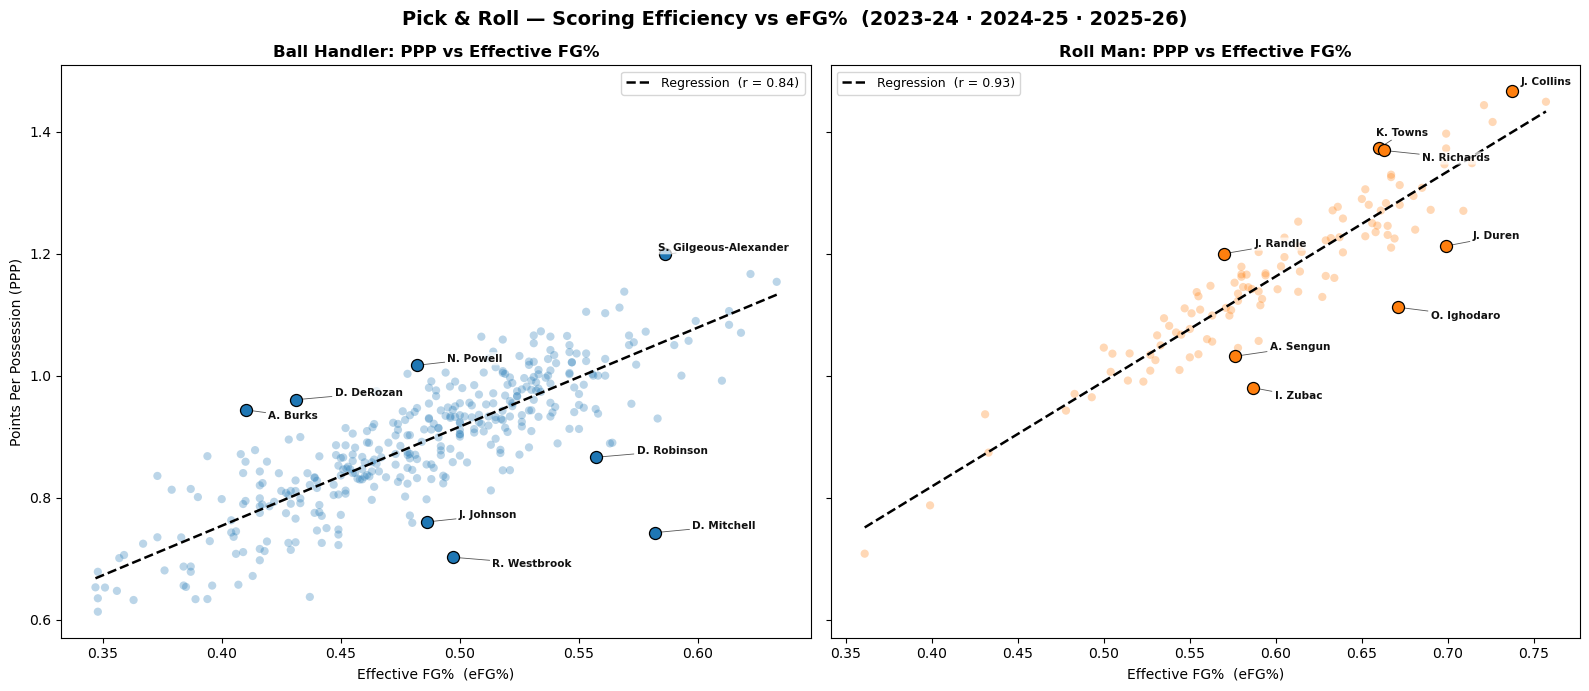

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, (play_type, group) in zip(axes, p&r_data.groupby("PlayType")):
    color = palette[play_type]
    ax.scatter(group["EFG_PCT"], group["PPP"], color=color, alpha=0.3, edgecolors="none", s=35)
    slope, intercept, _ = add_regression(ax, group["EFG_PCT"].values, group["PPP"].values)
    label_outliers(ax, group, "EFG_PCT", "PPP", slope, intercept, color)
    ax.set_title(f"{play_type}: PPP vs Effective FG%", fontsize=12, fontweight="bold")
    ax.set_xlabel("Effective FG%  (eFG%)")
    if ax is axes[0]:
        ax.set_ylabel("Points Per Possession (PPP)")
    ax.legend(fontsize=9)
fig.suptitle(f"Pick & Roll — Scoring Efficiency vs eFG%  ({' · '.join(recent_seasons)})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/plot4_ppp_vs_efg.png", dpi=150)
plt.show()

### Plot 5 — Metric Correlation Heatmap

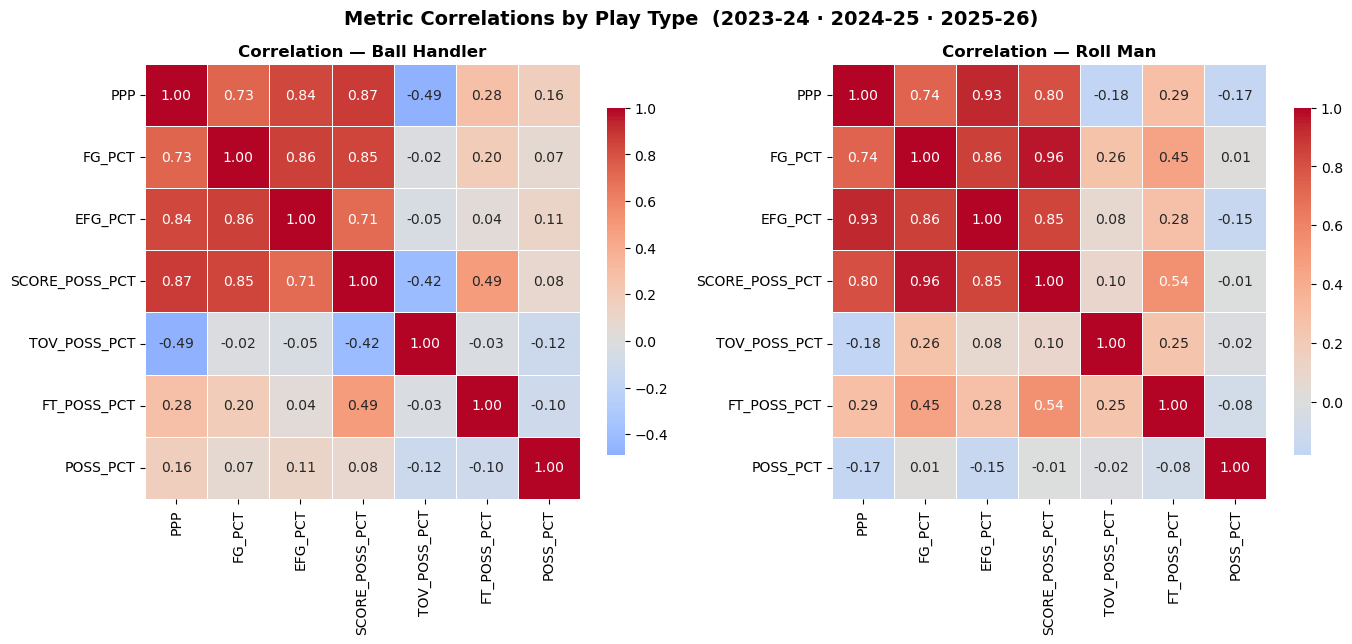

In [14]:
corr_cols = ["PPP", "FG_PCT", "EFG_PCT", "SCORE_POSS_PCT",
             "TOV_POSS_PCT", "FT_POSS_PCT", "POSS_PCT"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (play_type, group) in zip(axes, p&r_data.groupby("PlayType")):
    corr = group[corr_cols].corr()
    sns.heatmap(corr, ax=ax, annot=True, fmt=".2f", cmap="coolwarm",
                center=0, linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
    ax.set_title(f"Correlation — {play_type}", fontsize=12, fontweight="bold")
plt.suptitle(f"Metric Correlations by Play Type  ({' · '.join(recent_seasons)})",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/plot5_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Plot 6 — PPP vs Score Frequency




In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, (play_type, group) in zip(axes, p&r_data.groupby("PlayType")):
    color = palette[play_type]
    ax.scatter(group["SCORE_POSS_PCT"], group["PPP"], color=color, alpha=0.3, edgecolors="none", s=35)
    slope, intercept, _ = add_regression(ax, group["SCORE_POSS_PCT"].values, group["PPP"].values)
    label_outliers(ax, group, "SCORE_POSS_PCT", "PPP", slope, intercept, color)
    ax.set_title(f"{play_type}: PPP vs Score Frequency", fontsize=12, fontweight="bold")
    ax.set_xlabel("Score Frequency  (% of possessions resulting in points)")
    if ax is axes[0]:
        ax.set_ylabel("Points Per Possession (PPP)")
    ax.legend(fontsize=9)
fig.suptitle(f"Pick & Roll — PPP vs Score Frequency  ({' · '.join(recent_seasons)})",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{PROJECT_DIR}/plot6_ppp_vs_score_freq.png", dpi=150)
plt.show()

NameError: name 'p' is not defined

In [11]:
top_100_ppp = p&r_data.nlargest(100, "PPP")
print(top_100_ppp["PPP"].mean())

top_100_fg = p&r_data.nlargest(100, "FG_PCT")
print(top_100_fg["FG_PCT"].mean())

1.198612749976615
0.5837234273399042
